# Load libraries

In [93]:
import pandas as pd
import numpy as np

# Load data

In [94]:

df = pd.read_csv("googleplaystore.csv")
df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [95]:
unique_genres = set([ elem for sublist in [x for x in df["Genres"].str.split(";")] for elem in sublist ])
print(unique_genres)

genres_df = pd.DataFrame({"genre_id": range(1,len(unique_genres)+1), "genre": list(unique_genres)})

{'Arcade', 'Education', 'Libraries & Demo', 'Racing', 'Medical', 'Card', 'Puzzle', 'Pretend Play', 'Music & Audio', 'February 11, 2018', 'Action & Adventure', 'Business', 'Beauty', 'Role Playing', 'Auto & Vehicles', 'Art & Design', 'Sports', 'Trivia', 'Productivity', 'Action', 'Photography', 'Parenting', 'Comics', 'Maps & Navigation', 'Music & Video', 'Entertainment', 'Events', 'Food & Drink', 'Tools', 'Weather', 'Health & Fitness', 'Strategy', 'Casual', 'Personalization', 'Finance', 'Board', 'Creativity', 'Communication', 'Casino', 'Lifestyle', 'Music', 'House & Home', 'Adventure', 'Word', 'Educational', 'Social', 'Travel & Local', 'Video Players & Editors', 'Shopping', 'Simulation', 'Brain Games', 'Books & Reference', 'Dating', 'News & Magazines'}


In [96]:
categories_df = pd.DataFrame({"category_id": range(1,len(df["Category"].unique())+1), "category_name": df["Category"].unique()})

In [97]:
types_df = pd.DataFrame({"type_id": range(1,len(df["Type"].unique())+1), "type": df["Type"].unique()})
types_df.head(5)



,type_id,type
0,1,Free
1,2,Paid
2,3,NaN
3,4,0


In [98]:
content_ratings_df = pd.DataFrame({"content_rating_id": range(1,len(df["Content Rating"].unique())+1), "content_rating": df["Content Rating"].unique()})
content_ratings_df.head(5)

,content_rating_id,content_rating
0,1,Everyone
1,2,Teen
2,3,Everyone 10+
3,4,Mature 17+
4,5,Adults only 18+


In [99]:
# DATA SUMMARY
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [100]:
#sum of number of ratings
df["Rating"].sum()

np.float64(39279.0)

In [101]:
# AVERAGE RATING OF FREE APPS
df[df["Type"] == "Free"]["Rating"].mean()

np.float64(4.186202546163551)

In [102]:
#AVERAGE RATING OF PAID APPS
df[df["Type"] == "Paid"]["Rating"].mean()

np.float64(4.26661514683153)

# DATA CLEANING

In [103]:
# COUNT THE NUMBER OF ROWS
len(df)

10841

Seems like we have some null values, specially in rating

In [104]:
df.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [105]:
# FILL THE NULL VALUES IN THE DATASET WITH UKNOWN
df.fillna("Unknown", inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_19796\2627681849.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


In [106]:
df.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

We opted for this solution since 1474/10841 represents arround 13%, but there are outliers so applying the mean is risky, and the mode might work, but we have more than
9.000 ratings, so it's more than enough to get insights and we want to focus on the most accurate information 

In [107]:
df.to_csv("cleaned_dataset.csv", index=False)   

In [108]:
# WE FOUND February 11, 2018 IN GENRES COLUMN, WE WILL REPLACE IT WITH UNKNOWN
df["Genres"] = df["Genres"].replace("February 11, 2018", "Unknown")

In [109]:
# DISPLAY THE UNIQUE VALUES IN THE "CATEGORY" COLUMN
df["Category"].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [110]:
# AGAIN WE FOUND A VALUE IN THE CATEGORY COLUMN THAT DOES NOT BELONG THERE, WE WILL REPLACE IT WITH UNKNOWN
df["Category"] = df["Category"].replace("1.9", "Unknown")

In [111]:
# CHECK IF THERE ARE ANY DUPLICATE ROWS IN THE DATASET
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 483


In [112]:
# REMOVE DUPLICATE ROWS
df.drop_duplicates(inplace=True)

# Visualization

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   App             10358 non-null  object
 1   Category        10358 non-null  object
 2   Rating          10358 non-null  object
 3   Reviews         10358 non-null  object
 4   Size            10358 non-null  object
 5   Installs        10358 non-null  object
 6   Type            10358 non-null  object
 7   Price           10358 non-null  object
 8   Content Rating  10358 non-null  object
 9   Genres          10358 non-null  object
 10  Last Updated    10358 non-null  object
 11  Current Ver     10358 non-null  object
 12  Android Ver     10358 non-null  object
dtypes: object(13)
memory usage: 1.1+ MB


In [114]:
df.head(1)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up


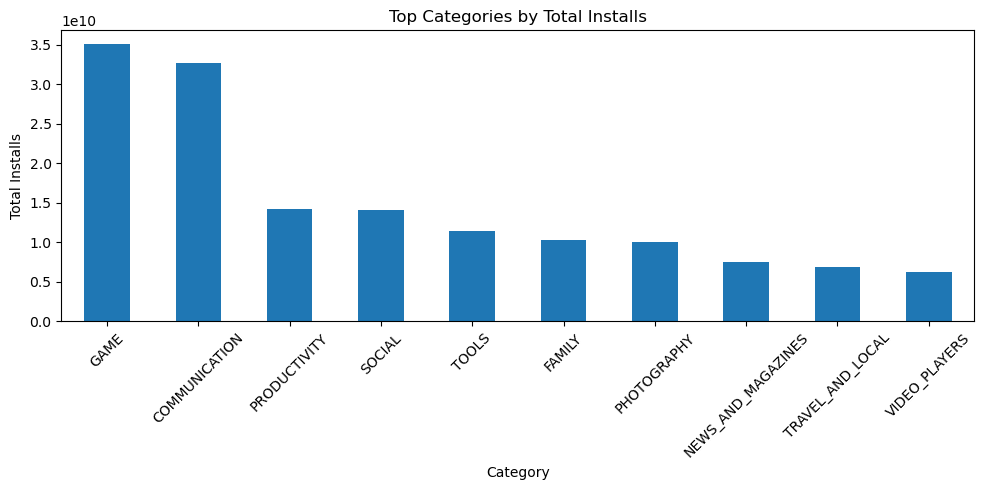

In [115]:
# Total installs by category
installs_by_category = df_viz.groupby("Category")["Installs_clean"].sum()

# Get top 10 categories
top_installs_categories = installs_by_category.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_installs_categories.plot(kind="bar")

plt.title("Top Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [116]:
# AVERAGE OF INSTALLS
average_installs = df_viz["Installs_clean"].mean()
print(f"Average Installs: {average_installs}")


Average Installs: 15465765.613709752


In [117]:
import pandas as pd

# Load your dataset
df = pd.read_csv("googleplaystore.csv")

# --- Clean Installs safely ---
df["Installs_clean"] = (
    df["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

# --- Clean Rating safely ---
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep only rows with usable Category + installs + rating
df_clean = df.dropna(subset=["Category", "Installs_clean", "Rating_clean"]).copy()

# Calculate category-level averages
category_stats = df_clean.groupby("Category").agg({
    "Installs_clean": "mean",
    "Rating_clean": "mean"
}).reset_index()

# Calculate global averages (across categories)
avg_install_rate = category_stats["Installs_clean"].mean()
avg_rating = category_stats["Rating_clean"].mean()

# Filter categories: higher installs but lower ratings
result = category_stats[
    (category_stats["Installs_clean"] > avg_install_rate) &
    (category_stats["Rating_clean"] < avg_rating)
].sort_values("Installs_clean", ascending=False)

# Display result
print("Categories with higher installs but lower ratings:")
print(result)


Categories with higher installs but lower ratings:
              Category  Installs_clean  Rating_clean
6        COMMUNICATION    9.953427e+07      4.158537
31       VIDEO_PLAYERS    3.888686e+07      4.063750
21  NEWS_AND_MAGAZINES    3.217258e+07      4.132189
24         PHOTOGRAPHY    3.182411e+07      4.192114
30    TRAVEL_AND_LOCAL    3.039318e+07      4.109292
9        ENTERTAINMENT    1.925611e+07      4.126174
29               TOOLS    1.560044e+07      4.047411


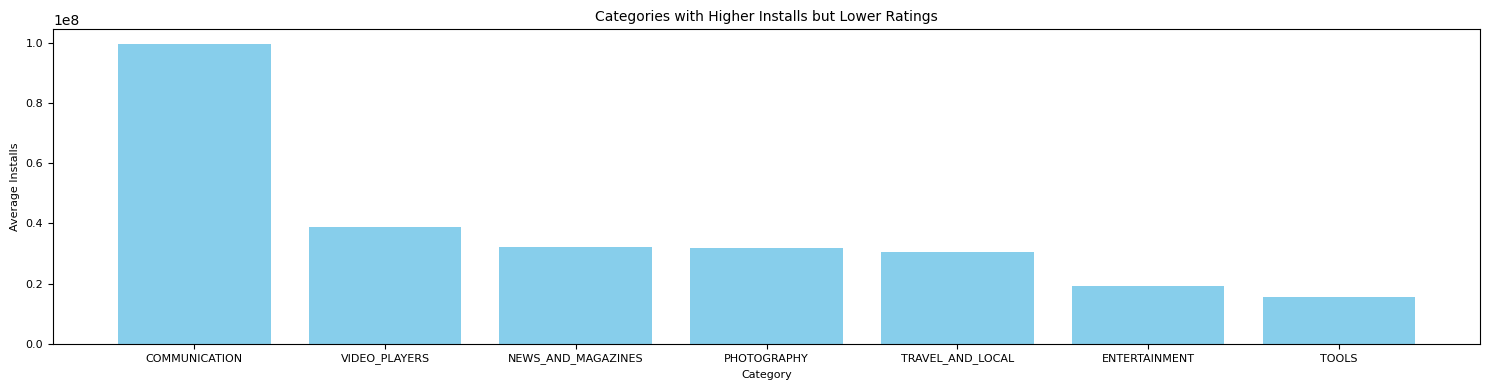

In [119]:
# CATEGORIES WITH HIGHER INSTALLS BUT LOWER RATINGS
plt.figure(figsize=(15,4))
plt.bar(result["Category"], result["Installs_clean"], color="skyblue")
plt.title("Categories with Higher Installs but Lower Ratings", fontsize=10)
plt.xlabel("Category", fontsize=8)
plt.ylabel("Average Installs", fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()
